# 🏠 California Housing — EDA

**Objective:** Explore the California housing dataset to understand the factors driving median house prices and prepare for a regression model.

**Dataset:** 500 synthetic housing records with features: `med_income`, `house_age`, `avg_rooms`, `avg_bedrooms`, `population`, `avg_occupancy`, `latitude`, `longitude`, and target `price`.

**Notebook structure:**
1. Setup & Imports
2. Data Generation
3. Data Overview
4. Missing Values
5. Target (Price) Distribution
6. Correlation with Price
7. Feature Relationships
8. Insights & Conclusions

In [1]:
# 1. Setup & Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

print("Setup complete.")

Setup complete.


In [2]:
# 2. Data Generation (synthetic, reproducible)
def generate_housing(n: int = 500, seed: int = 42) -> pd.DataFrame:
    """Generate a synthetic California housing-like dataset."""
    rng = np.random.default_rng(seed)
    med_income = rng.lognormal(mean=np.log(5), sigma=0.5, size=n)
    house_age = rng.uniform(0, 50, size=n)
    avg_rooms = rng.normal(6, 2, size=n).clip(2, 15)
    avg_bedrooms = avg_rooms * rng.uniform(0.15, 0.25, size=n)
    population = rng.poisson(500, size=n)
    avg_occupancy = rng.uniform(2, 6, size=n)
    latitude = rng.uniform(32.5, 42.0, size=n)
    longitude = rng.uniform(-124, -114, size=n)

    price = (
        -2.5 * med_income
        + 0.3 * house_age
        + 3.0 * avg_rooms
        - 2.0 * avg_bedrooms
        + 0.001 * population
        + 0.5 * avg_occupancy
        + 50 * (latitude - 37)
        - 30 * (longitude + 119)
        + rng.normal(0, 15, size=n)
        + 200
    ).clip(50, 500)

    df = pd.DataFrame({
        "med_income": med_income,
        "house_age": house_age,
        "avg_rooms": avg_rooms,
        "avg_bedrooms": avg_bedrooms,
        "population": population,
        "avg_occupancy": avg_occupancy,
        "latitude": latitude,
        "longitude": longitude,
        "price": price,
    })
    return df.round(2)


df = generate_housing(500)
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(10)

Dataset shape: 500 rows × 9 columns


,med_income,house_age,avg_rooms,avg_bedrooms,population,avg_occupancy,latitude,longitude,price
0,5.82,18.61,5.39,0.89,502,5.71,33.08,-116.54,50.00
1,2.97,7.68,5.03,0.89,490,3.67,33.95,-116.49,50.00
2,7.28,30.04,7.74,1.40,466,2.01,35.65,-122.10,261.24
3,8.00,5.98,8.96,1.46,546,2.25,38.87,-123.38,435.83
4,1.88,18.25,9.59,1.97,506,2.44,36.67,-119.51,221.83
5,2.61,47.92,8.63,1.90,485,2.38,39.47,-121.98,455.97
6,5.33,49.77,5.78,0.91,509,3.41,40.74,-117.01,359.70
7,4.27,38.61,6.71,1.33,496,4.81,39.70,-120.43,394.09
8,4.96,15.55,7.53,1.72,473,5.16,41.93,-119.51,480.95
9,3.26,34.38,6.24,1.40,497,4.36,39.67,-122.87,487.74


In [3]:
# 3. Data Overview
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Statistical Summary ===")
df.describe().T

=== Data Types ===
med_income       float64
house_age        float64
avg_rooms        float64
avg_bedrooms     float64
population         int64
avg_occupancy    float64
latitude         float64
longitude        float64
price            float64
dtype: object

=== Statistical Summary ===


,count,mean,std,min,25%,50%,75%,max
med_income,500.0,5.58146,2.900229,1.39,3.5775,5.010,6.7050,21.46
house_age,500.0,24.90600,14.765509,0.06,12.1650,24.495,37.9400,49.94
avg_rooms,500.0,6.06074,1.994494,2.00,4.7325,6.050,7.3825,11.62
avg_bedrooms,500.0,1.21490,0.435419,0.32,0.9275,1.180,1.4725,2.42
population,500.0,499.19200,21.478403,432.00,485.0000,498.000,514.0000,570.00
avg_occupancy,500.0,3.96274,1.153711,2.00,3.0275,3.985,4.9925,6.00
latitude,500.0,37.25068,2.678528,32.52,34.9650,37.230,39.3825,41.99
longitude,500.0,-119.14622,2.927446,-123.99,-121.7275,-119.230,-116.5375,-114.02
price,500.0,235.73094,137.757131,50.00,110.5600,236.845,340.5050,500.00


In [4]:
# 4. Missing Values Check
missing = df.isnull().sum()
print("=== Missing Values ===")
print(missing[missing > 0] if missing.any() else "No missing values found. ✅")

# Duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

=== Missing Values ===
No missing values found. ✅

Duplicate rows: 0


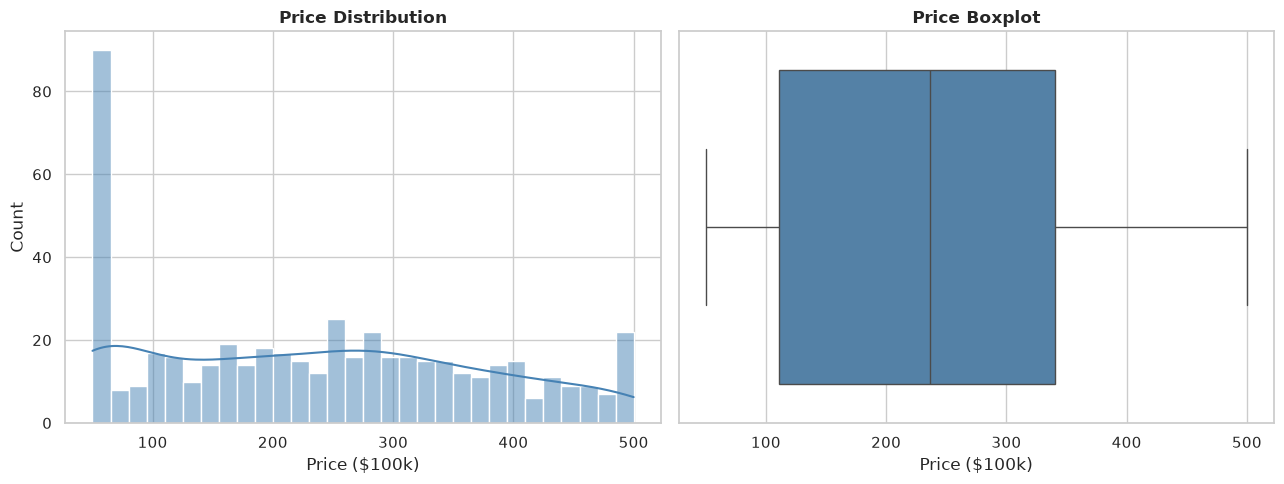

Price stats:
count    500.00
mean     235.73
std      137.76
min       50.00
25%      110.56
50%      236.84
75%      340.50
max      500.00
Name: price, dtype: float64


In [5]:
# 5. Target (Price) Distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["price"], kde=True, ax=axes[0], color="steelblue", bins=30)
axes[0].set_title("Price Distribution", fontweight="bold")
axes[0].set_xlabel("Price ($100k)")

sns.boxplot(x=df["price"], ax=axes[1], color="steelblue")
axes[1].set_title("Price Boxplot", fontweight="bold")
axes[1].set_xlabel("Price ($100k)")

plt.tight_layout()
plt.show()

print(f"Price stats:\n{df['price'].describe().round(2)}")

=== Correlation with Price ===
latitude         0.821
avg_bedrooms     0.075
population       0.057
avg_rooms        0.056
house_age        0.052
med_income       0.040
avg_occupancy   -0.043
longitude       -0.485
dtype: float64


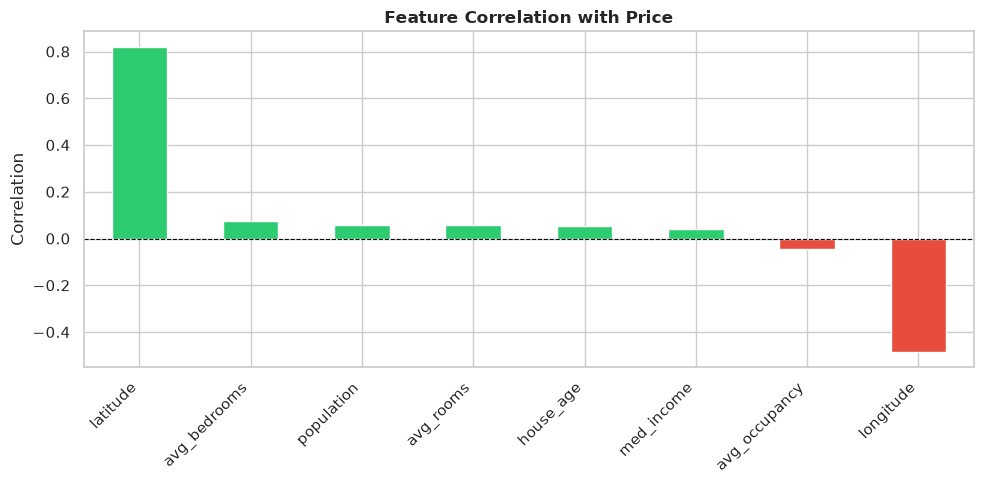

In [6]:
# 6. Correlation with Price
feature_cols = [c for c in df.columns if c != "price"]
corr_with_price = df[feature_cols].corrwith(df["price"]).sort_values(ascending=False)

print("=== Correlation with Price ===")
print(corr_with_price.round(3))

# Bar plot
plt.figure(figsize=(10, 5))
corr_with_price.plot(kind="bar", color=["#2ecc71" if v > 0 else "#e74c3c" for v in corr_with_price])
plt.title("Feature Correlation with Price", fontweight="bold")
plt.ylabel("Correlation")
plt.xticks(rotation=45, ha="right")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

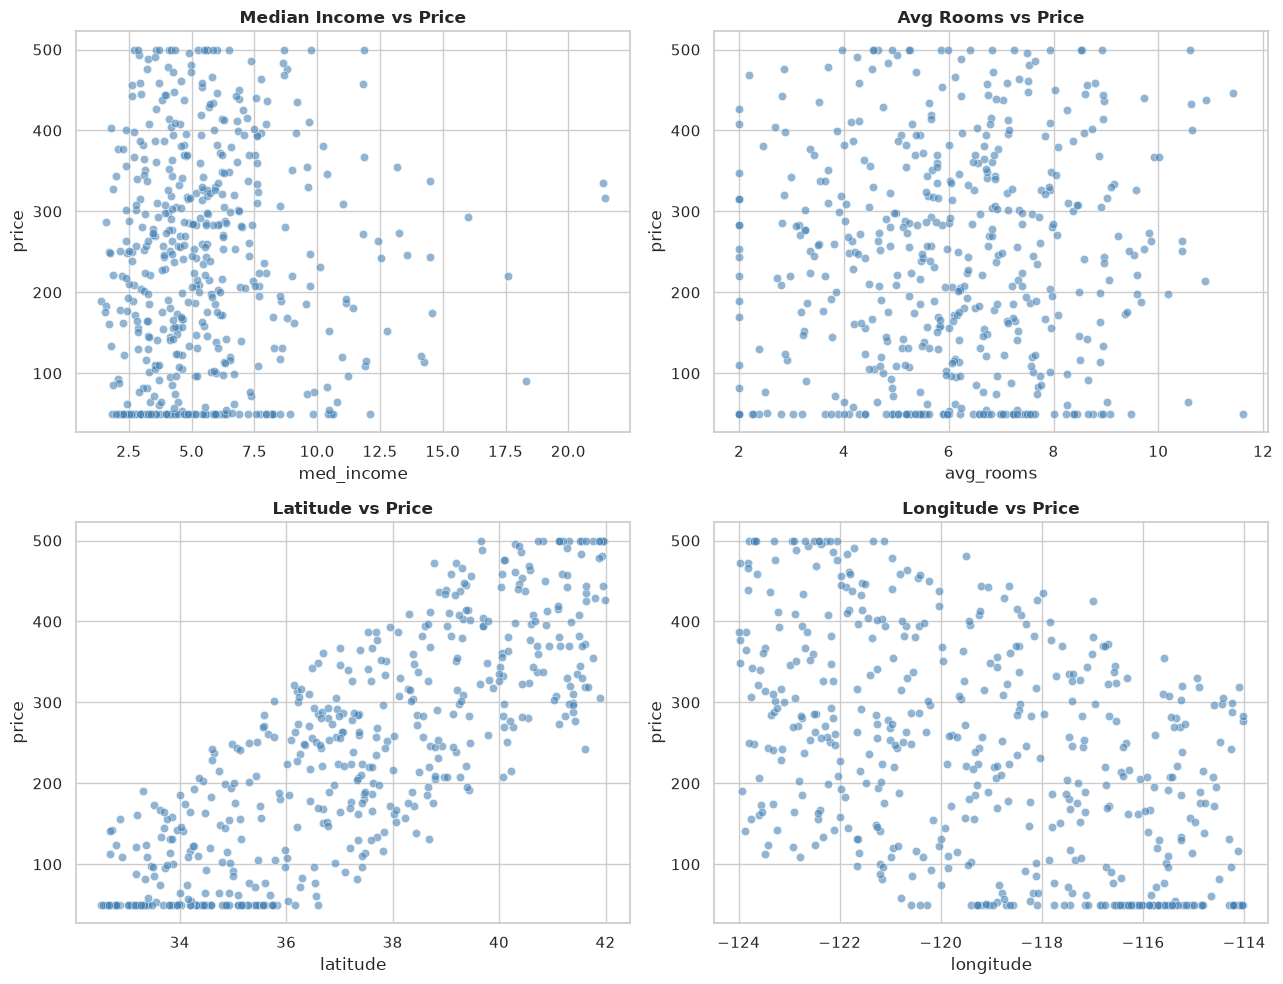

In [7]:
# 7a. Scatter Plots — Key Features vs Price
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
scatter_pairs = [
    ("med_income", "Median Income vs Price"),
    ("avg_rooms", "Avg Rooms vs Price"),
    ("latitude", "Latitude vs Price"),
    ("longitude", "Longitude vs Price"),
]

for ax, (col, title) in zip(axes.flatten(), scatter_pairs):
    sns.scatterplot(data=df, x=col, y="price", ax=ax, alpha=0.6, color="steelblue")
    ax.set_title(title, fontweight="bold")

plt.tight_layout()
plt.show()

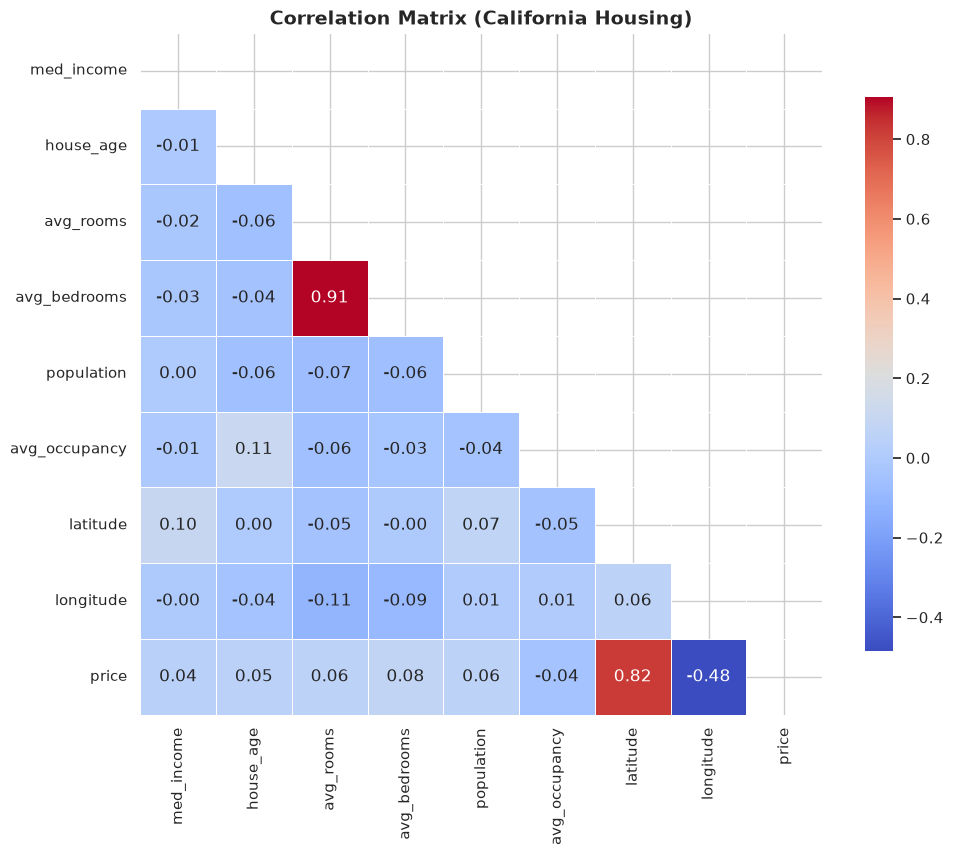

In [8]:
# 7b. Correlation Heatmap
plt.figure(figsize=(11, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", mask=mask,
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix (California Housing)", fontsize=14, fontweight="bold")
plt.show()

## 📌 Insights & Conclusions

1. **No missing values** — the dataset is clean and ready for modeling.
2. **Median income is the strongest driver** of house price (strong positive correlation).
3. **Geographic features matter** — latitude and longitude show meaningful correlation with price, reflecting regional price differences.
4. **Rooms & occupancy** have moderate positive relationships with price.
5. **Modeling implication:**
   - Linear models (Linear/Ridge Regression) are appropriate given the mostly linear relationships.
   - Consider feature scaling for `med_income`, `population`, and `avg_rooms`.
   - `avg_bedrooms` is highly correlated with `avg_rooms` — watch for multicollinearity.